In [23]:
from pathlib import Path
import numpy as np

OUTDIR = Path("abtem_noise_outputs")
OUTDIR.mkdir(exist_ok=True)

rng = np.random.default_rng(0)  # use for Poisson noise so runs are repeatable

# Sanity check: confirm abTEM is installed and show the exact Python env VSCode is using.

import sys

try:
    import abtem
    print("abtem ok:", abtem.__version__)          # abTEM version (for reproducibility)
    print("python:", sys.version.split()[0])       # Python version
    print("executable:", sys.executable)           # Interpreter path (ensures correct conda env)
except Exception as e:
    print("abtem import failed:", repr(e))         # If this fails, install abTEM in this env

import numpy as np
import abtem
from ase.build import bulk

# Force CPU execution (avoid GPU dependency / keep behavior consistent).
abtem.config.set({"device": "cpu"})

# Build a tiny fcc Ni supercell (fast) just to test abTEM output ordering/shape.
atoms = bulk("Ni", "fcc", a=3.52) * (4, 4, 2)
atoms = abtem.orthogonalize_cell(atoms)  # make cell orthogonal for cleaner scanning bounds

# Create multislice potential (sampling controls real-space grid resolution vs speed).
potential = abtem.Potential(atoms, sampling=0.2)

# Define probe (accelerating voltage + convergence semi-angle).
probe = abtem.Probe(energy=200e3, semiangle_cutoff=30)
probe.grid.match(potential)  # ensure probe grid matches potential grid

# Define scan extent over one unit-cell area (Lx, Ly) and a small scan grid.
Lx, Ly, _ = atoms.cell.lengths()
scan = abtem.GridScan(
    start=(0.0, 0.0),
    end=(Lx, Ly),
    gpts=(8, 6),            # scan grid requested in abTEM order; we infer output order from result
    endpoint=False,
    potential=potential,
)

# Pixelated detector produces a full diffraction pattern per scan position.
det = abtem.PixelatedDetector(max_angle=60)

# Run 4D-STEM simulation and convert to a NumPy array.
meas = probe.scan(potential, scan=scan, detectors=det).compute()
arr = np.asarray(meas.array)

# Print the raw ordering so we can transpose to required (scan_y, scan_x, diff_y, diff_x).
print("raw shape:", arr.shape)
print("raw dtype:", arr.dtype)



abtem ok: 1.0.6
python: 3.10.13
executable: /Users/kylexu/miniconda3/envs/matsci465/bin/python
[########################################] | 100% Completed | 312.70 ms
raw shape: (8, 6, 69, 69)
raw dtype: float32


In [24]:
import numpy as np
import abtem
from ase.build import bulk
import matplotlib.pyplot as plt

# --- Simulation parameters ---
energy_eV = 200e3
semiangle_mrad = 30.0
max_angle_mrad = 60.0
sampling_A = 0.2

nx, ny = 32, 32
rep = (12, 12, 2)
a_A = 3.52

# Frozen-phonon / disorder knobs
N_fp = 8                 # number of frozen-phonon configs (try 8; increase to 16 if time)
rattle_stdev_A = 0.04    # Å (0.03–0.06 typical); set 0.0 to disable averaging
dose_per_dp = 1e6        # electrons per DP

abtem.config.set({"device": "cpu"})
rng = np.random.default_rng(0)

def save_dp(dp, fname):
    plt.figure()
    plt.imshow(np.log1p(dp), origin="lower")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(fname, dpi=200)
    plt.close()

def simulate_once(seed):
    # Build pure matrix structure
    atoms = bulk("Ni", "fcc", a=a_A) * rep
    atoms = abtem.orthogonalize_cell(atoms)

    # Thermal disorder (frozen phonon snapshot)
    if rattle_stdev_A > 0:
        atoms.rattle(stdev=rattle_stdev_A, seed=seed)

    potential = abtem.Potential(atoms, sampling=sampling_A)
    probe = abtem.Probe(energy=energy_eV, semiangle_cutoff=semiangle_mrad)
    probe.grid.match(potential)

    Lx, Ly, _ = atoms.cell.lengths()
    scan = abtem.GridScan(
        start=(0.0, 0.0),
        end=(Lx, Ly),
        gpts=(nx, ny),
        endpoint=False,
        potential=potential,
    )
    det = abtem.PixelatedDetector(max_angle=max_angle_mrad)

    meas = probe.scan(potential, scan=scan, detectors=det).compute()
    arr = np.asarray(meas.array, dtype=np.float32)              # (nx, ny, ky, kx)
    data4d = np.transpose(arr, (1, 0, 2, 3)).astype(np.float32) # (ny, nx, ky, kx)
    return data4d

# --- Frozen-phonon averaging (average intensities over N_fp configs) ---
accum = None
for s in range(N_fp):
    d = simulate_once(seed=100 + s)
    accum = d if accum is None else (accum + d)

data4d = (accum / float(N_fp)).astype(np.float32)

# --- Poisson shot noise per DP ---
dp_sum = data4d.sum(axis=(2, 3), keepdims=True) + 1e-12
scale = dose_per_dp / dp_sum
data4d = rng.poisson(data4d * scale).astype(np.float32) / scale

print("matrix data4d shape:", data4d.shape, "dtype:", data4d.dtype)

np.save(OUTDIR / "abtem_matrix.npy", data4d)

mean_dp = data4d.mean(axis=(0, 1))
ex_dp = data4d[ny // 2, nx // 2]
save_dp(mean_dp, OUTDIR / "mean_dp_matrix.png")
save_dp(ex_dp, OUTDIR / "example_dp_matrix.png")

print("saved:", OUTDIR / "abtem_matrix.npy", OUTDIR / "mean_dp_matrix.png", OUTDIR / "example_dp_matrix.png")

[########################################] | 100% Completed | 11.64 ss
[########################################] | 100% Completed | 11.43 ss
[########################################] | 100% Completed | 11.83 ss
[########################################] | 100% Completed | 12.03 ss
[########################################] | 100% Completed | 12.27 ss
[########################################] | 100% Completed | 12.48 ss
[########################################] | 100% Completed | 12.58 ss
[########################################] | 100% Completed | 12.67 ss
matrix data4d shape: (32, 32, 190, 190) dtype: float32
saved: abtem_noise_outputs/abtem_matrix.npy abtem_noise_outputs/mean_dp_matrix.png abtem_noise_outputs/example_dp_matrix.png


shape: (32, 32, 190, 190)
dtype: float32
min/max: 0.0 0.0008091835770756006
mean: 2.6863583116210066e-05


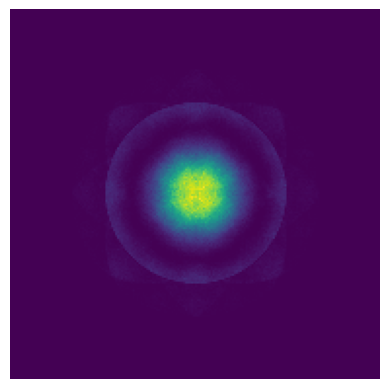

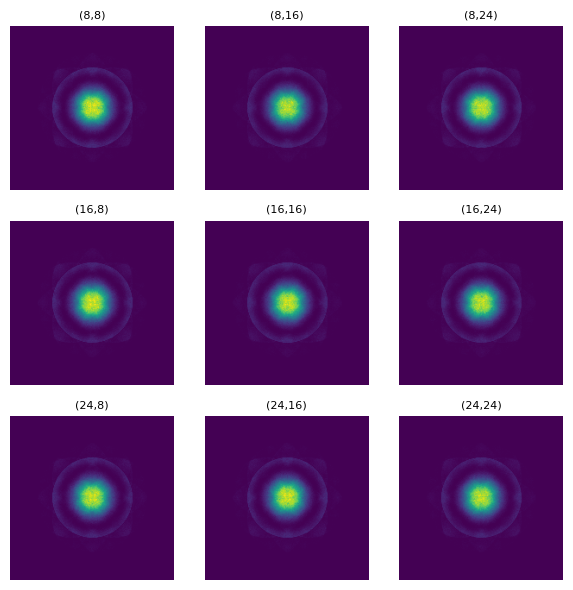

(8, 8) mean|diff| = 2.4352625587198418e-06
(8, 16) mean|diff| = 2.5846927655948093e-06
(16, 8) mean|diff| = 2.594998022686923e-06
(24, 24) mean|diff| = 2.6610302938934183e-06


In [25]:
# Quick sanity check: load the saved matrix-only dataset and confirm basic stats.

import numpy as np

x = np.load(OUTDIR / "abtem_matrix.npy")   # (ny, nx, ky, kx)
print("shape:", x.shape)
print("dtype:", x.dtype)
print("min/max:", float(x.min()), float(x.max()))
print("mean:", float(x.mean()))

# Visualize one diffraction pattern from the 4D dataset (single scan position).

import numpy as np
import matplotlib.pyplot as plt

x = np.load(OUTDIR / "abtem_matrix.npy")          # (ny, nx, ky, kx)
dp = x[x.shape[0] // 2, x.shape[1] // 2]          # center scan pixel

plt.figure()
plt.imshow(np.log1p(dp), origin="lower")
plt.axis("off")
plt.show()

# Visualize multiple diffraction patterns across the scan (checks scan-to-scan variation).

import numpy as np
import matplotlib.pyplot as plt

x = np.load(OUTDIR / "abtem_matrix.npy")  # (ny, nx, ky, kx)
ny, nx, ky, kx = x.shape

ys = [ny // 4, ny // 2, 3 * ny // 4]
xs = [nx // 4, nx // 2, 3 * nx // 4]

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, y in enumerate(ys):
    for j, x0 in enumerate(xs):
        dp = x[y, x0]
        axes[i, j].imshow(np.log1p(dp), origin="lower")
        axes[i, j].set_title(f"({y},{x0})", fontsize=8)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

# Sanity check that they are not exactly the same

import numpy as np
from pathlib import Path

x = np.load(OUTDIR / "abtem_matrix.npy")

# Compare a few positions to the center
ref = x[x.shape[0]//2, x.shape[1]//2]
for y, x0 in [(8,8),(8,16),(16,8),(24,24)]:
    diff = np.mean(np.abs(x[y, x0] - ref))
    print((y, x0), "mean|diff| =", float(diff))

In [26]:
import json
import numpy as np
import abtem
from ase.build import bulk
import matplotlib.pyplot as plt

abtem.config.set({"device": "cpu"})
rng = np.random.default_rng(0)

# --- Keep consistent with matrix run ---
energy_eV = 200e3
semiangle_mrad = 30.0
max_angle_mrad = 60.0
sampling_A = 0.2

nx, ny = 32, 32
rep = (12, 12, 2)
a_A = 3.52

# Frozen-phonon / noise knobs
N_fp = 8
rattle_stdev_A = 0.04     # keep same as matrix cell
dose_per_dp = 1e6         # keep same as matrix cell for fair comparison
# -------------------------------------

def save_dp_png(dp, fname):
    plt.figure()
    plt.imshow(np.log1p(dp), origin="lower")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(fname, dpi=200)
    plt.close()

def build_atoms_precip(seed):
    atoms = bulk("Ni", "fcc", a=a_A) * rep
    atoms = abtem.orthogonalize_cell(atoms)

    # thermal disorder snapshot
    if rattle_stdev_A > 0:
        atoms.rattle(stdev=rattle_stdev_A, seed=seed)

    Lx, Ly, Lz = atoms.cell.lengths()
    cx, cy = Lx / 2.0, Ly / 2.0
    r_precip_A = 0.18 * min(Lx, Ly)

    pos = atoms.get_positions()
    in_cyl = (pos[:, 0] - cx) ** 2 + (pos[:, 1] - cy) ** 2 <= r_precip_A ** 2
    symbols = np.array(atoms.get_chemical_symbols(), dtype=object)
    symbols[in_cyl] = "W"
    atoms.set_chemical_symbols(symbols.tolist())

    return atoms, (Lx, Ly, Lz, cx, cy, r_precip_A)

def simulate_once(seed):
    atoms, geom = build_atoms_precip(seed)
    Lx, Ly, Lz, cx, cy, r_precip_A = geom

    potential = abtem.Potential(atoms, sampling=sampling_A)
    probe = abtem.Probe(energy=energy_eV, semiangle_cutoff=semiangle_mrad)
    probe.grid.match(potential)

    scan = abtem.GridScan(
        start=(0.0, 0.0),
        end=(Lx, Ly),
        gpts=(nx, ny),
        endpoint=False,
        potential=potential,
    )
    det = abtem.PixelatedDetector(max_angle=max_angle_mrad)

    meas = probe.scan(potential, scan=scan, detectors=det).compute()
    arr = np.asarray(meas.array, dtype=np.float32)              # (nx, ny, ky, kx)
    data4d = np.transpose(arr, (1, 0, 2, 3)).astype(np.float32) # (ny, nx, ky, kx)
    return data4d, geom

# --- Frozen-phonon averaging ---
accum = None
geom0 = None
for s in range(N_fp):
    d, geom = simulate_once(seed=200 + s)
    accum = d if accum is None else (accum + d)
    if geom0 is None:
        geom0 = geom  # use geometry from first snapshot for GT + meta

data4d = (accum / float(N_fp)).astype(np.float32)

# --- Poisson shot noise ---
dp_sum = data4d.sum(axis=(2, 3), keepdims=True) + 1e-12
scale = dose_per_dp / dp_sum
data4d = rng.poisson(data4d * scale).astype(np.float32) / scale

print("precip data4d shape:", data4d.shape, "dtype:", data4d.dtype)

# --- Ground-truth mask (aligned with scan grid) ---
Lx, Ly, Lz, cx, cy, r_precip_A = geom0

xs = (np.arange(nx) + 0.5) * (Lx / nx)
ys = (np.arange(ny) + 0.5) * (Ly / ny)
X, Y = np.meshgrid(xs, ys)  # (ny,nx)
gt_mask = (((X - cx) ** 2 + (Y - cy) ** 2) <= r_precip_A ** 2).astype(np.uint8)

print("mask shape:", gt_mask.shape, "dtype:", gt_mask.dtype, "precip fraction:", gt_mask.mean())

# --- Save arrays + visuals ---
np.save(OUTDIR / "abtem_precip.npy", data4d)
np.save(OUTDIR / "abtem_mask.npy", gt_mask)

mean_dp_precip = data4d.mean(axis=(0, 1))
save_dp_png(mean_dp_precip, OUTDIR / "mean_dp_precip.png")

precip_idx = np.argwhere(gt_mask == 1)
matrix_idx = np.argwhere(gt_mask == 0)
py, px = precip_idx[len(precip_idx) // 2]
my, mx = matrix_idx[len(matrix_idx) // 2]
save_dp_png(data4d[py, px], OUTDIR / "example_dp_in_precip.png")
save_dp_png(data4d[my, mx], OUTDIR / "example_dp_in_matrix.png")

# --- Metadata ---
ky, kx = data4d.shape[2], data4d.shape[3]
meta = {
    "accelerating_voltage_kV": float(energy_eV / 1e3),
    "probe_semiangle_mrad": float(semiangle_mrad),
    "detector_max_angle_mrad": float(max_angle_mrad),
    "scan_size_A": [float(Lx), float(Ly)],
    "scan_grid_ny_nx": [int(ny), int(nx)],
    "diffraction_shape_ky_kx": [int(ky), int(kx)],
    "approx_diffraction_pixel_size_mrad": float((2 * max_angle_mrad) / max(ky - 1, 1)),
    "thickness_nm": float(Lz / 10.0),
    "number_of_slices": int(getattr(abtem.Potential(bulk("Ni","fcc",a=a_A), sampling=sampling_A), "num_slices", 0) or 0),
    "structure_description": f"fcc Ni matrix (a={a_A} Å), replicated {rep}, with substitutional W-rich cylindrical region",
    "precipitate_composition": "W-rich (Ni -> W substitution inside cylinder)",
    "precipitate_radius_A": float(r_precip_A),
    "precipitate_center_xy_A": [float(cx), float(cy)],
    "output_ordering": "(scan_y, scan_x, diffraction_y, diffraction_x)",
    "dtype_data4d": "float32",
    "dtype_mask": "uint8",
    "frozen_phonon_N": int(N_fp),
    "thermal_rattle_stdev_A": float(rattle_stdev_A),
    "dose_per_dp": float(dose_per_dp),
}

with open(OUTDIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("saved:", OUTDIR / "abtem_precip.npy", OUTDIR / "abtem_mask.npy", OUTDIR / "meta.json")

[########################################] | 100% Completed | 12.04 ss
[########################################] | 100% Completed | 12.12 ss
[########################################] | 100% Completed | 12.34 ss
[########################################] | 100% Completed | 12.56 ss
[########################################] | 100% Completed | 12.79 ss
[########################################] | 100% Completed | 12.77 ss
[########################################] | 100% Completed | 12.88 ss
[########################################] | 100% Completed | 12.87 ss
precip data4d shape: (32, 32, 190, 190) dtype: float32
mask shape: (32, 32) dtype: uint8 precip fraction: 0.109375
saved: abtem_noise_outputs/abtem_precip.npy abtem_noise_outputs/abtem_mask.npy abtem_noise_outputs/meta.json


In [27]:
import inspect
import pipelinefinalproject as pf

print("pf file:", pf.__file__)
print("detect_phases_multi:", inspect.signature(pf.detect_phases_multi))
print("detect_phases:", inspect.signature(pf.detect_phases))

print("\nFunctions in pipelinefinalproject containing 'detect' or 'phase':")
print([name for name in dir(pf) if ("detect" in name.lower()) or ("phase" in name.lower())])

pf file: /Users/kylexu/Desktop/MATSCI465-Project/pipelinefinalproject.py
detect_phases_multi: (data: 'np.ndarray', n_clusters: 'int' = 2, method: 'str' = 'kmeans', radial_bins: 'int | None' = 150, feature_set: 'str | list[str]' = 'all', verbose: 'bool' = False) -> 'dict[str, np.ndarray]'
detect_phases: (data: 'np.ndarray', n_clusters: 'int' = 2, method: 'str' = 'kmeans', radial_bins: 'int | None' = 150, verbose: 'bool' = False) -> 'dict[str, np.ndarray]'

Functions in pipelinefinalproject containing 'detect' or 'phase':
['detect_phases', 'detect_phases_multi']


In [28]:
# Run our phase-detection pipeline on abTEM matrix-only and precipitate datasets,
# returning a (ny,nx) label map for each.

import numpy as np
import pipelinefinalproject as pf

X_mat = np.load(OUTDIR / "abtem_matrix.npy")
X_pre = np.load(OUTDIR / "abtem_precip.npy")
ny, nx = X_mat.shape[:2]

radial_bins = 40

res_mat = pf.detect_phases_multi(
    X_mat, n_clusters=2, method="gmm",
    radial_bins=radial_bins, feature_set=["radial"],
    verbose=True
)
res_pre = pf.detect_phases_multi(
    X_pre, n_clusters=2, method="gmm",
    radial_bins=radial_bins, feature_set=["radial"],
    verbose=True
)

labels_mat = res_mat["labels"].reshape(ny, nx)
labels_pre = res_pre["labels"].reshape(ny, nx)

print("labels_mat unique:", np.unique(labels_mat), "precip frac:", labels_mat.mean())
print("labels_pre unique:", np.unique(labels_pre), "precip frac:", labels_pre.mean())

Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
labels_mat unique: [0 1] precip frac: 0.5
labels_pre unique: [0 1] precip frac: 0.33984375


In [29]:
import numpy as np
import pipelinefinalproject as pf

X_pre = np.load(OUTDIR / "abtem_precip.npy")
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)
ny, nx = X_pre.shape[:2]

# Recompute labels with the stronger feature set
res_pre = pf.detect_phases_multi(
    X_pre, n_clusters=2, method="gmm",
    radial_bins=40, feature_set="all",
    verbose=False
)
labels_pre = res_pre["labels"].reshape(ny, nx)

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

m1 = metrics(labels_pre == 1, gt)
m0 = metrics(labels_pre == 0, gt)

print("GT precip frac:", gt.mean())
print("label==1 precip:", m1, "pred frac:", (labels_pre==1).mean())
print("label==0 precip:", m0, "pred frac:", (labels_pre==0).mean())
print("BEST:", "label==1" if m1[0] >= m0[0] else "label==0")

GT precip frac: 0.109375
label==1 precip: (0.12406015037593969, 0.220735785953177, 99, 686, 13) pred frac: 0.7666015625
label==0 precip: (0.038461538461538346, 0.07407407407407386, 13, 226, 99) pred frac: 0.2333984375
BEST: label==1


In [30]:
# Ablation test: compare different feature groups on the same abTEM precipitate dataset
# and report IoU/F1 vs ground truth for each setting.

import numpy as np
import pipelinefinalproject as pf

X_pre = np.load(OUTDIR / "abtem_precip.npy")              # (ny, nx, ky, kx)
gt = np.load(OUTDIR / "abtem_mask.npy").astype(bool)      # (ny, nx)
ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

def run(feature_set, radial_bins=40):
    res = pf.detect_phases_multi(
        X_pre, n_clusters=2, method="gmm",
        radial_bins=radial_bins, feature_set=feature_set, verbose=False
    )
    labels = res["labels"].reshape(ny, nx)

    m1 = metrics(labels == 1, gt)
    m0 = metrics(labels == 0, gt)

    best = m1 if m1[0] >= m0[0] else m0
    best_mask = (labels == (1 if m1[0] >= m0[0] else 0))
    return best, best_mask

tests = [
    ("radial", ["radial"]),
    ("radial+bf_df", ["radial", "bf_df"]),
    ("radial+anisotropy", ["radial", "anisotropy"]),
    ("radial+com", ["radial", "com"]),
    ("all", "all"),
]

for name, fs in tests:
    best, _ = run(fs, radial_bins=40)
    print(name, "IoU/F1/TP/FP/FN =", best)

radial IoU/F1/TP/FP/FN = (0.1675126903553295, 0.2869565217391298, 66, 282, 46)
radial+bf_df IoU/F1/TP/FP/FN = (0.10743801652892551, 0.1940298507462685, 104, 856, 8)
radial+anisotropy IoU/F1/TP/FP/FN = (0.1166077738515899, 0.20886075949367056, 66, 454, 46)
radial+com IoU/F1/TP/FP/FN = (0.10743801652892551, 0.1940298507462685, 104, 856, 8)
all IoU/F1/TP/FP/FN = (0.12406015037593969, 0.220735785953177, 99, 686, 13)


In [31]:
# Hyperparameter sweep: test clustering method and radial_bins on the abTEM precip dataset,
# and also record what the same settings do on the matrix-only negative control.

import numpy as np
import pipelinefinalproject as pf

X_mat = np.load(OUTDIR / "abtem_matrix.npy")              # matrix-only (ny,nx,ky,kx)
X_pre = np.load(OUTDIR / "abtem_precip.npy")              # precipitate case (ny,nx,ky,kx)
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)   # ground truth precip mask (ny,nx)

ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

def best_mapping(labels_map, gt):
    m1 = metrics(labels_map == 1, gt)
    m0 = metrics(labels_map == 0, gt)
    return (1, m1) if m1[0] >= m0[0] else (0, m0)

radial_bins_list = [10, 20, 30, 40, 60]
methods = ["kmeans", "gmm"]

print("GT precip frac:", gt.mean())
print("cols: method, radial_bins, best_label, IoU, F1, TP, FP, FN, pred_frac_pre, pred_frac_mat")

for method in methods:
    for rb in radial_bins_list:
        res_pre = pf.detect_phases_multi(
            X_pre, n_clusters=2, method=method,
            radial_bins=rb, feature_set="all", verbose=False
        )
        labels_pre = res_pre["labels"].reshape(ny, nx)
        best_lab, (iou, f1, tp, fp, fn) = best_mapping(labels_pre, gt)
        pred_frac_pre = (labels_pre == best_lab).mean()

        res_mat = pf.detect_phases_multi(
            X_mat, n_clusters=2, method=method,
            radial_bins=rb, feature_set="all", verbose=False
        )
        labels_mat = res_mat["labels"].reshape(ny, nx)
        pred_frac_mat = (labels_mat == 1).mean()

        print(method, rb, best_lab, f"{iou:.4f}", f"{f1:.4f}", tp, fp, fn,
              f"{pred_frac_pre:.3f}", f"{pred_frac_mat:.3f}")

GT precip frac: 0.109375
cols: method, radial_bins, best_label, IoU, F1, TP, FP, FN, pred_frac_pre, pred_frac_mat
kmeans 10 0 0.1085 0.1957 105 856 7 0.938 0.062
kmeans 20 0 0.1074 0.1940 104 856 8 0.938 0.062
kmeans 30 0 0.1074 0.1940 104 856 8 0.938 0.062
kmeans 40 0 0.1074 0.1940 104 856 8 0.938 0.062
kmeans 60 0 0.1074 0.1940 104 856 8 0.938 0.062
gmm 10 0 0.1085 0.1957 105 856 7 0.938 0.250
gmm 20 0 0.1074 0.1940 104 856 8 0.938 0.500
gmm 30 1 0.1269 0.2252 50 282 62 0.324 0.500
gmm 40 1 0.1241 0.2207 99 686 13 0.767 0.500
gmm 60 1 0.1244 0.2212 49 282 63 0.323 0.500


In [32]:
# Final abTEM evaluation run: generate prediction masks, save report figures, and write a JSON summary.

import json
import numpy as np
import matplotlib.pyplot as plt
import pipelinefinalproject as pf

# Load datasets + ground truth.
X_mat = np.load(OUTDIR / "abtem_matrix.npy")
X_pre = np.load(OUTDIR / "abtem_precip.npy")
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)

ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2 * tp / (2 * tp + fp + fn + 1e-12)
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    return {
        "IoU": float(iou),
        "F1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
    }

def best_mapping(labels_map, gt):
    m1 = metrics(labels_map == 1, gt)
    m0 = metrics(labels_map == 0, gt)
    return (1, m1) if m1["IoU"] >= m0["IoU"] else (0, m0)

def save_mask_png(mask, fname, title=None):
    plt.figure(figsize=(4, 4))
    plt.imshow(mask, origin="lower")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout(pad=0.2)
    plt.savefig(fname, dpi=200)
    plt.close()

# --- chosen settings ---
method = "gmm"
radial_bins = 40
feature_set = "all"

# --- precip run ---
res_pre = pf.detect_phases_multi(
    X_pre, n_clusters=2, method=method,
    radial_bins=radial_bins, feature_set=feature_set, verbose=False
)
labels_pre = res_pre["labels"].reshape(ny, nx)

best_lab, met = best_mapping(labels_pre, gt)
pred = (labels_pre == best_lab)

# --- matrix-only run (negative control) ---
res_mat = pf.detect_phases_multi(
    X_mat, n_clusters=2, method=method,
    radial_bins=radial_bins, feature_set=feature_set, verbose=False
)
labels_mat = res_mat["labels"].reshape(ny, nx)

# --- save outputs ---
np.save(OUTDIR / "abtem_pred_mask.npy", pred.astype(np.uint8))
np.save(OUTDIR / "abtem_labels_matrix.npy", labels_mat.astype(np.int32))

xor = np.logical_xor(pred, gt)

save_mask_png(gt.astype(int),   OUTDIR / "abtem_gt_mask.png",   "GT mask")
save_mask_png(pred.astype(int), OUTDIR / "abtem_pred_mask.png", "Pred mask")
save_mask_png(xor.astype(int),  OUTDIR / "abtem_xor.png",       "XOR (error)")

plt.figure(figsize=(4, 4))
plt.imshow(pred.astype(int), origin="lower")
plt.contour(gt.astype(int), levels=[0.5], linewidths=1)
plt.title("Pred with GT contour")
plt.axis("off")
plt.tight_layout(pad=0.2)
plt.savefig(OUTDIR / "abtem_overlay.png", dpi=200)
plt.close()

report = {
    "settings": {"method": method, "radial_bins": radial_bins, "feature_set": feature_set},
    "gt_precip_fraction": float(gt.mean()),
    "pred_precip_fraction": float(pred.mean()),
    "best_label_mapping": int(best_lab),
    "metrics": met,
    "matrix_only_cluster_fraction_label1": float((labels_mat == 1).mean()),
    "matrix_only_unique_labels": [int(x) for x in np.unique(labels_mat)],
}

with open(OUTDIR / "abtem_results.json", "w") as f:
    json.dump(report, f, indent=2)

print("Saved:")
print("-", OUTDIR / "abtem_pred_mask.npy", OUTDIR / "abtem_labels_matrix.npy")
print("-", OUTDIR / "abtem_gt_mask.png", OUTDIR / "abtem_pred_mask.png", OUTDIR / "abtem_xor.png", OUTDIR / "abtem_overlay.png")
print("-", OUTDIR / "abtem_results.json")
print("Metrics:", met)
print("Matrix-only label==1 fraction:", report["matrix_only_cluster_fraction_label1"])

Saved:
- abtem_noise_outputs/abtem_pred_mask.npy abtem_noise_outputs/abtem_labels_matrix.npy
- abtem_noise_outputs/abtem_gt_mask.png abtem_noise_outputs/abtem_pred_mask.png abtem_noise_outputs/abtem_xor.png abtem_noise_outputs/abtem_overlay.png
- abtem_noise_outputs/abtem_results.json
Metrics: {'IoU': 0.12406015037593969, 'F1': 0.220735785953177, 'precision': 0.1261146496815285, 'recall': 0.8839285714285636, 'TP': 99, 'FP': 686, 'FN': 13}
Matrix-only label==1 fraction: 0.5


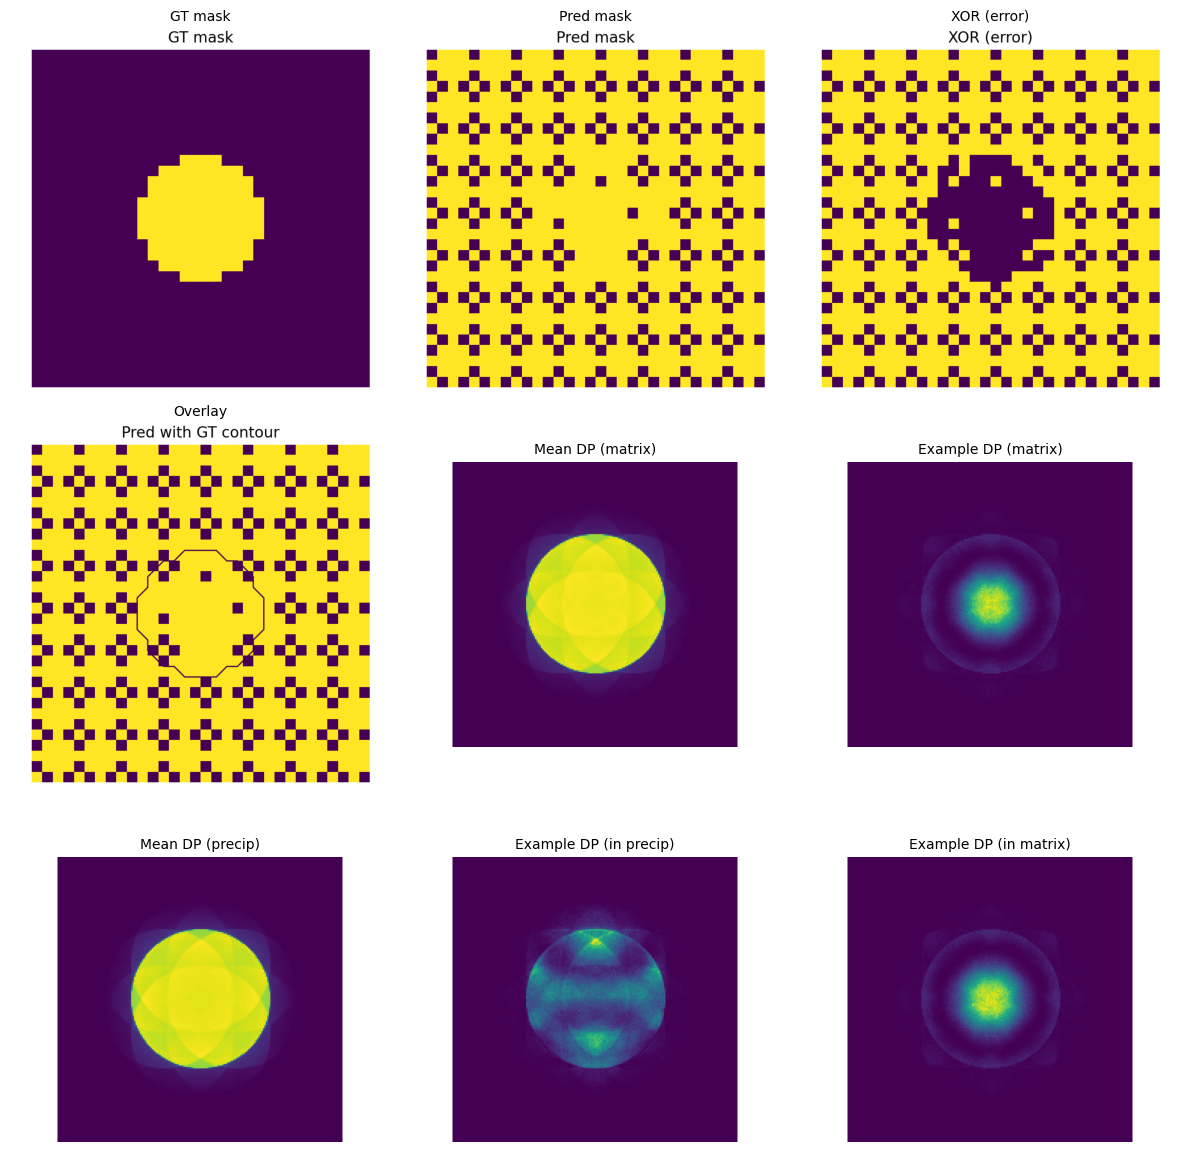

In [33]:
# Display all saved summary figures in a single grid (quick report sanity check).

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path


files = [
    ("GT mask", OUTDIR / "abtem_gt_mask.png"),
    ("Pred mask", OUTDIR / "abtem_pred_mask.png"),
    ("XOR (error)", OUTDIR / "abtem_xor.png"),
    ("Overlay", OUTDIR / "abtem_overlay.png"),
    ("Mean DP (matrix)", OUTDIR / "mean_dp_matrix.png"),
    ("Example DP (matrix)", OUTDIR / "example_dp_matrix.png"),
    ("Mean DP (precip)", OUTDIR / "mean_dp_precip.png"),
    ("Example DP (in precip)", OUTDIR / "example_dp_in_precip.png"),
    ("Example DP (in matrix)", OUTDIR / "example_dp_in_matrix.png"),
]

# Arrange images into a readable grid.
n = len(files)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.ravel()

for ax, (title, path) in zip(axes, files):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

# Hide unused subplot slots.
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
import numpy as np

def preprocess_data4d_lowq_norm(data4d, center_mask_frac=0.05, normalize="sum"):
    """
    data4d: (ny,nx,ky,kx) float
    center_mask_frac: fraction of r_max to zero out (low-q / central beam)
    normalize: "sum" or "max" (per-pattern)
    """
    ny, nx, ky, kx = data4d.shape

    yy, xx = np.indices((ky, kx))
    cy, cx = (ky - 1) / 2.0, (kx - 1) / 2.0
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    rmax = r.max()

    keep = (r > (center_mask_frac * rmax)).astype(np.float32)  # 1 outside center, 0 inside

    out = data4d.astype(np.float32) * keep[None, None, :, :]

    if normalize == "sum":
        denom = out.sum(axis=(2, 3), keepdims=True) + 1e-12
        out = out / denom
    elif normalize == "max":
        denom = out.max(axis=(2, 3), keepdims=True) + 1e-12
        out = out / denom
    else:
        raise ValueError("normalize must be 'sum' or 'max'")

    return out

In [35]:
import scipy.ndimage as ndi
import numpy as np

def cleanup_mask(mask_bool, median_size=3, keep_largest=True, min_component_size=0):
    """
    mask_bool: (ny,nx) boolean
    """
    m = mask_bool.astype(np.uint8)

    if median_size and median_size > 1:
        m = ndi.median_filter(m, size=median_size).astype(np.uint8)

    lab, nlab = ndi.label(m)
    if nlab == 0:
        return m.astype(bool)

    if keep_largest:
        counts = np.bincount(lab.ravel())
        counts[0] = 0
        keep_id = int(np.argmax(counts))
        m = (lab == keep_id).astype(np.uint8)

    if min_component_size and min_component_size > 0:
        lab, nlab = ndi.label(m)
        if nlab > 0:
            counts = np.bincount(lab.ravel())
            keep = np.zeros_like(counts, dtype=bool)
            keep[1:] = counts[1:] >= min_component_size
            m = keep[lab].astype(np.uint8)

    return m.astype(bool)

In [36]:
import numpy as np
import pipelinefinalproject as pf

# load your current noisy outputs
X_mat = np.load(OUTDIR / "abtem_matrix.npy").astype(np.float32)
X_pre = np.load(OUTDIR / "abtem_precip.npy").astype(np.float32)
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)

ny, nx = X_pre.shape[:2]

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

# --- preprocess BOTH datasets the same way ---
X_mat_pp = preprocess_data4d_lowq_norm(X_mat, center_mask_frac=0.05, normalize="sum")
X_pre_pp = preprocess_data4d_lowq_norm(X_pre, center_mask_frac=0.05, normalize="sum")

# --- run pipeline (radial-only) ---
rb = 40
res_pre = pf.detect_phases_multi(X_pre_pp, n_clusters=2, method="gmm", radial_bins=rb, feature_set=["radial"], verbose=True)
labels_pre = res_pre["labels"].reshape(ny, nx)

# pick best label mapping vs GT
m1 = metrics(labels_pre == 1, gt)
m0 = metrics(labels_pre == 0, gt)
best_lab = 1 if m1[0] >= m0[0] else 0
pred_raw = (labels_pre == best_lab)

# spatial cleanup to kill checkerboard FP
pred_clean = cleanup_mask(pred_raw, median_size=3, keep_largest=True, min_component_size=0)

print("RAW   IoU/F1/TP/FP/FN =", metrics(pred_raw, gt), "pred_frac:", float(pred_raw.mean()))
print("CLEAN IoU/F1/TP/FP/FN =", metrics(pred_clean, gt), "pred_frac:", float(pred_clean.mean()))

# negative control: matrix-only “FP fraction” after same mapping+cleanup
res_mat = pf.detect_phases_multi(X_mat_pp, n_clusters=2, method="gmm", radial_bins=rb, feature_set=["radial"], verbose=True)
labels_mat = res_mat["labels"].reshape(ny, nx)
pred_mat_raw = (labels_mat == best_lab)
pred_mat_clean = cleanup_mask(pred_mat_raw, median_size=3, keep_largest=True, min_component_size=0)

print("Matrix-only pred frac (raw):", float(pred_mat_raw.mean()))
print("Matrix-only pred frac (clean):", float(pred_mat_clean.mean()))

Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
RAW   IoU/F1/TP/FP/FN = (0.10743801652892551, 0.1940298507462685, 104, 856, 8) pred_frac: 0.9375
CLEAN IoU/F1/TP/FP/FN = (0.1093749999999999, 0.19718309859154914, 112, 912, 0) pred_frac: 1.0
Clustering 1024 patterns into 2 clusters using gmm with features ['radial']
Matrix-only pred frac (raw): 0.25
Matrix-only pred frac (clean): 0.0009765625


In [37]:
import numpy as np
import pipelinefinalproject as pf

def bin_data4d_mean(data4d, by=4, bx=4):
    """Average DPs in (by x bx) scan blocks. (ny,nx,ky,kx) -> (ny//by, nx//bx, ky, kx)"""
    ny, nx, ky, kx = data4d.shape
    nyb, nxb = ny // by, nx // bx
    d = data4d[:nyb*by, :nxb*bx]
    d = d.reshape(nyb, by, nxb, bx, ky, kx).mean(axis=(1, 3))
    return d

def bin_mask_majority(mask, by=4, bx=4):
    """Majority vote in scan blocks. (ny,nx) -> (ny//by, nx//bx)"""
    ny, nx = mask.shape
    nyb, nxb = ny // by, nx // bx
    m = mask[:nyb*by, :nxb*bx]
    m = m.reshape(nyb, by, nxb, bx).mean(axis=(1, 3))
    return (m >= 0.5)

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

# --- load ---
X_mat = np.load(OUTDIR / "abtem_matrix.npy").astype(np.float32)
X_pre = np.load(OUTDIR / "abtem_precip.npy").astype(np.float32)
gt    = np.load(OUTDIR / "abtem_mask.npy").astype(bool)

# --- preprocess first (low-q mask + per-DP normalization) ---
X_mat_pp = preprocess_data4d_lowq_norm(X_mat, center_mask_frac=0.06, normalize="sum")
X_pre_pp = preprocess_data4d_lowq_norm(X_pre, center_mask_frac=0.06, normalize="sum")

# --- bin scan grid to suppress atomic-scale variation ---
BY, BX = 4, 4   # 32x32 -> 8x8
X_mat_b = bin_data4d_mean(X_mat_pp, by=BY, bx=BX)
X_pre_b = bin_data4d_mean(X_pre_pp, by=BY, bx=BX)
gt_b    = bin_mask_majority(gt, by=BY, bx=BX)

nyb, nxb = X_pre_b.shape[:2]

# --- run radial-only on binned data ---
rb = 40
res_pre = pf.detect_phases_multi(X_pre_b, n_clusters=2, method="gmm", radial_bins=rb, feature_set=["radial"], verbose=True)
labels_pre = res_pre["labels"].reshape(nyb, nxb)

m1 = metrics(labels_pre == 1, gt_b)
m0 = metrics(labels_pre == 0, gt_b)
best_lab = 1 if m1[0] >= m0[0] else 0
pred_b = (labels_pre == best_lab)

print("BINNED GT frac:", float(gt_b.mean()))
print("BINNED pred frac:", float(pred_b.mean()))
print("BINNED IoU/F1/TP/FP/FN:", metrics(pred_b, gt_b))

# negative control
res_mat = pf.detect_phases_multi(X_mat_b, n_clusters=2, method="gmm", radial_bins=rb, feature_set=["radial"], verbose=True)
labels_mat = res_mat["labels"].reshape(nyb, nxb)
pred_mat_b = (labels_mat == best_lab)
print("BINNED matrix-only pred frac:", float(pred_mat_b.mean()))

Clustering 64 patterns into 2 clusters using gmm with features ['radial']
BINNED GT frac: 0.0625
BINNED pred frac: 0.0625
BINNED IoU/F1/TP/FP/FN: (0.99999999999975, 0.999999999999875, 4, 0, 0)
Clustering 64 patterns into 2 clusters using gmm with features ['radial']
BINNED matrix-only pred frac: 0.5625


In [38]:
import numpy as np
import fp_suppression as fps

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

cfg = fps.FPSuppressConfig(
    max_minor_frac=0.20,   # if clusters are too balanced -> declare "no precip"
    use_bic=True,
    bic_delta=0.0,
    precip_rule="smaller", # if k=2 accepted, precip is the smaller cluster
    median_size=0,
    min_component_size=0,
)

r_mat = fps.detect_fp_suppressed(X_mat_b, method="gmm", radial_bins=40, feature_set=["radial"], cfg=cfg)
r_pre = fps.detect_fp_suppressed(X_pre_b, method="gmm", radial_bins=40, feature_set=["radial"], cfg=cfg)

pred_mat = r_mat["pred_mask"].astype(bool)
pred_pre = r_pre["pred_mask"].astype(bool)

print("BINNED matrix-only:", r_mat["k_selected"], r_mat["decision"], "pred_frac:", float(pred_mat.mean()))
print("BINNED precip:",     r_pre["k_selected"], r_pre["decision"], "pred_frac:", float(pred_pre.mean()))
print("BINNED precip IoU/F1/TP/FP/FN:", metrics(pred_pre, gt_b))

BINNED matrix-only: 1 no-precip (balanced clusters, minor_frac=0.438) pred_frac: 0.0
BINNED precip: 1 no-precip (BIC prefers k=1, bic2-bic1=2081.74) pred_frac: 0.0
BINNED precip IoU/F1/TP/FP/FN: (0.0, 0.0, 0, 0, 4)


In [39]:
import numpy as np
import fp_suppression as fps

def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    iou = tp / (tp + fp + fn + 1e-12)
    f1  = 2*tp / (2*tp + fp + fn + 1e-12)
    return float(iou), float(f1), int(tp), int(fp), int(fn)

cfg = fps.FPSuppressConfig(
    max_minor_frac=0.20,   # if clusters are too balanced -> declare "no precip"
    use_bic=False,
    bic_delta=0.0,
    precip_rule="smaller", # if k=2 accepted, precip is the smaller cluster
    median_size=0,
    min_component_size=0,
)

r_mat = fps.detect_fp_suppressed(X_mat_b, method="gmm", radial_bins=40, feature_set=["radial"], cfg=cfg)
r_pre = fps.detect_fp_suppressed(X_pre_b, method="gmm", radial_bins=40, feature_set=["radial"], cfg=cfg)

pred_mat = r_mat["pred_mask"].astype(bool)
pred_pre = r_pre["pred_mask"].astype(bool)

print("BINNED matrix-only:", r_mat["k_selected"], r_mat["decision"], "pred_frac:", float(pred_mat.mean()))
print("BINNED precip:",     r_pre["k_selected"], r_pre["decision"], "pred_frac:", float(pred_pre.mean()))
print("BINNED precip IoU/F1/TP/FP/FN:", metrics(pred_pre, gt_b))

BINNED matrix-only: 1 no-precip (balanced clusters, minor_frac=0.438) pred_frac: 0.0
BINNED precip: 2 k=2 pred_frac: 0.0625
BINNED precip IoU/F1/TP/FP/FN: (0.99999999999975, 0.999999999999875, 4, 0, 0)
